# Integrated Industrial Disaster Simulation

## Bhopal Gas Tragedy – Scenario-Based Hazard, Exposure and Evacuation Analysis

### Objective

This project develops an integrated simulation framework to analyze how a toxic industrial gas release propagates through a population and how emergency interventions such as faster alarms and evacuation can reduce population exposure and risk.

### Simulation Pipeline

Accident Initiation → Gas Release → Atmospheric Dispersion → Population Exposure → Evacuation → Risk Assessment → Scenario Comparison

In [1]:
import numpy as np

print(np.__version__)

2.4.6


In [2]:
# ============================================================
# MODULE 1: SIMULATION CONFIGURATION
# Integrated Industrial Disaster Simulation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# 1. INDUSTRIAL ACCIDENT SCENARIO
# ------------------------------------------------------------

scenario = {
    
    # Gas release
    "released_mass_kg": 40000,
    "release_duration_min": 60,
    
    # Atmospheric conditions
    "wind_speed_mps": 1.5,
    
    # Simulation geography
    "city_length_m": 5000,
    "city_width_m": 3000,
    
    # Population
    "population_size": 1000,
    
    # Simulation time
    "simulation_duration_min": 180,
    "time_step_min": 1
}

scenario

{'released_mass_kg': 40000,
 'release_duration_min': 60,
 'wind_speed_mps': 1.5,
 'city_length_m': 5000,
 'city_width_m': 3000,
 'population_size': 1000,
 'simulation_duration_min': 180,
 'time_step_min': 1}

In [3]:
# ============================================================
# MODULE 1: SIMULATION CONFIGURATION
# Integrated Industrial Disaster Simulation
# ============================================================

config = {
    "released_mass_kg": 40000,
    "release_duration_min": 60,
    "wind_speed_mps": 1.5,
    "city_length_m": 5000,
    "city_width_m": 3000,
    "population_size": 1000,
    "simulation_duration_min": 180,
    "time_step_min": 1
}

config

{'released_mass_kg': 40000,
 'release_duration_min': 60,
 'wind_speed_mps': 1.5,
 'city_length_m': 5000,
 'city_width_m': 3000,
 'population_size': 1000,
 'simulation_duration_min': 180,
 'time_step_min': 1}

# Module 1: Simulation Configuration

This module defines the baseline assumptions and parameters for the
integrated industrial disaster simulation.

The parameters control:

- MIC release characteristics
- Meteorological conditions
- Spatial dimensions of the affected city
- Population size
- Simulation horizon
- Temporal resolution

All subsequent modules use this configuration as the central simulation input.

# Module 2: Spatial Environment and Population Generation

This module creates a simplified spatial representation of the affected city
and generates population agents across the simulation area.

Each population agent represents an individual with:

- Spatial location
- Movement characteristics
- Exposure history
- Health risk status

The population distribution will later be combined with the gas dispersion
model to estimate individual and population-level exposure.

In [4]:
# ============================================================
# MODULE 2: SPATIAL ENVIRONMENT & POPULATION GENERATION
# Integrated Industrial Disaster Simulation
# ============================================================

# Set random seed for reproducibility
np.random.seed(42)

# Extract city dimensions from configuration
city_length = config["city_length_m"]
city_width = config["city_width_m"]
population_size = config["population_size"]

# ------------------------------------------------------------
# Define Industrial Accident Source Location
# ------------------------------------------------------------

source_x = 0
source_y = city_width / 2

# ------------------------------------------------------------
# Generate Population Agents
# ------------------------------------------------------------

population = pd.DataFrame({
    "agent_id": np.arange(population_size),

    # Initial spatial coordinates
    "x_position_m": np.random.uniform(
        0, city_length, population_size
    ),

    "y_position_m": np.random.uniform(
        0, city_width, population_size
    ),

    # Individual evacuation speed (m/min)
    "walking_speed_m_min": np.random.normal(
        loc=70,
        scale=15,
        size=population_size
    )
})

# Ensure realistic positive movement speeds
population["walking_speed_m_min"] = population[
    "walking_speed_m_min"
].clip(lower=30, upper=120)

# ------------------------------------------------------------
# Initialize Simulation Variables
# ------------------------------------------------------------

population["aware"] = False
population["exposure_dose"] = 0.0
population["risk_level"] = "Not Assessed"
population["evacuated"] = False

# Display first few agents
population.head()

,agent_id,x_position_m,y_position_m,walking_speed_m_min,aware,exposure_dose,risk_level,evacuated
0,0,1872.700594,555.398787,56.830261,False,0.0,Not Assessed,False
1,1,4753.571532,1625.702842,57.596795,False,0.0,Not Assessed,False
2,2,3659.969709,2618.837508,66.602817,False,0.0,Not Assessed,False
3,3,2993.292421,2196.674659,75.510483,False,0.0,Not Assessed,False
4,4,780.093202,2419.683444,83.703769,False,0.0,Not Assessed,False


# Module 3: Simplified MIC Dispersion and Hazard Field

This module models the downwind transport and crosswind dispersion of the
released toxic gas.

A simplified Gaussian dispersion framework is used to estimate relative gas
concentration across the simulated city.

The model incorporates:

- Release rate
- Wind transport
- Downwind distance
- Crosswind dispersion
- Time-dependent release duration

The resulting hazard field will be integrated with the population agents to
calculate individual exposure.

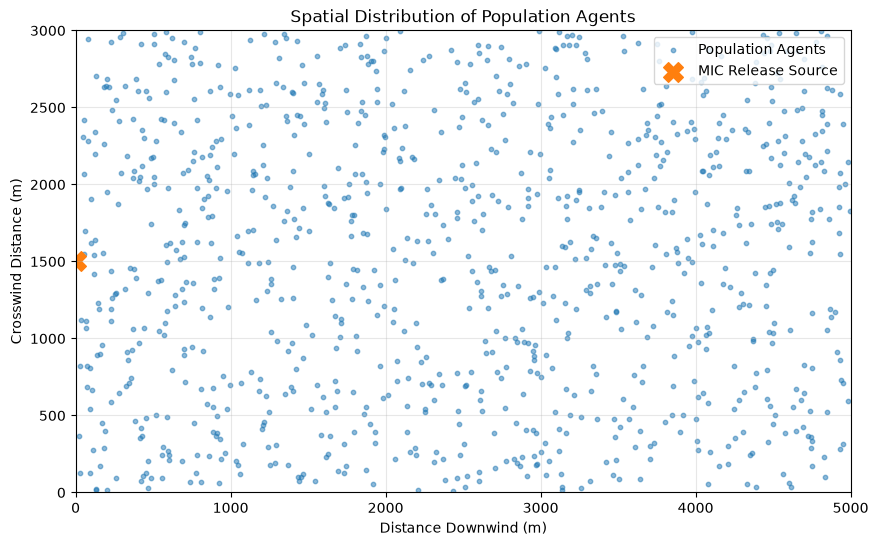

In [5]:
# ------------------------------------------------------------
# Visualize Spatial Environment
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    population["x_position_m"],
    population["y_position_m"],
    s=10,
    alpha=0.5,
    label="Population Agents"
)

# Mark industrial accident source
plt.scatter(
    source_x,
    source_y,
    s=200,
    marker="X",
    label="MIC Release Source"
)

plt.xlabel("Distance Downwind (m)")
plt.ylabel("Crosswind Distance (m)")
plt.title("Spatial Distribution of Population Agents")

plt.xlim(0, city_length)
plt.ylim(0, city_width)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [6]:
# ============================================================
# MODULE 3: MIC DISPERSION & HAZARD FIELD
# Simplified Analytical Scenario Model
# ============================================================

# Extract simulation parameters
released_mass_kg = config["released_mass_kg"]
release_duration_min = config["release_duration_min"]
wind_speed_mps = config["wind_speed_mps"]

# Convert release duration to seconds
release_duration_sec = release_duration_min * 60

# Average release rate (kg/s)
release_rate_kg_s = released_mass_kg / release_duration_sec

# Convert population coordinates into
# downwind and crosswind coordinates

x = population["x_position_m"].values
y = population["y_position_m"].values - source_y

print(f"Average release rate: {release_rate_kg_s:.2f} kg/s")
print(f"Wind speed: {wind_speed_mps:.2f} m/s")

Average release rate: 11.11 kg/s
Wind speed: 1.50 m/s


In [7]:
# ------------------------------------------------------------
# Simplified Dispersion Parameters
# ------------------------------------------------------------

def sigma_y(x):
    """
    Crosswind dispersion parameter.
    Simplified representation for scenario analysis.
    """
    x_safe = np.maximum(x, 1)

    return 0.12 * x_safe


def sigma_z(x):
    """
    Vertical dispersion parameter.
    Simplified representation for scenario analysis.
    """
    x_safe = np.maximum(x, 1)

    return 0.08 * x_safe

In [8]:
def gas_concentration(x, y, time_min):
    """
    Estimate simplified gas concentration at population locations.

    Parameters
    ----------
    x : array
        Downwind distance from source (m)

    y : array
        Crosswind distance from plume centerline (m)

    time_min : float
        Simulation time in minutes

    Returns
    -------
    concentration : array
        Relative concentration field
    """

    # Initialize concentration
    concentration = np.zeros_like(x, dtype=float)

    # Gas only released during release period
    if time_min > release_duration_min:
        return concentration

    # Gas travel distance based on wind speed
    gas_front_distance = (
        wind_speed_mps
        * time_min
        * 60
    )

    # Locations reached by gas
    reached = x <= gas_front_distance

    if np.any(reached):

        sy = sigma_y(x[reached])
        sz = sigma_z(x[reached])

        # Simplified Gaussian concentration model
        concentration[reached] = (
            release_rate_kg_s
            /
            (
                2
                * np.pi
                * wind_speed_mps
                * sy
                * sz
            )
            *
            np.exp(
                -0.5
                * (y[reached] / sy) ** 2
            )
        )

    return concentration

In [9]:
# ------------------------------------------------------------
# Test Gas Concentration at 30 Minutes
# ------------------------------------------------------------

test_time = 30

concentration = gas_concentration(
    x,
    y,
    test_time
)

population["gas_concentration"] = concentration

print(
    f"Maximum concentration: "
    f"{concentration.max():.6f}"
)

print(
    f"Population exposed at {test_time} minutes: "
    f"{np.sum(concentration > 0)} agents"
)

Maximum concentration: 0.000631
Population exposed at 30 minutes: 512 agents


# MODULE 4: Population Exposure and Risk Assessment

This module integrates gas concentration over time for each population agent
to estimate cumulative exposure and classify individual risk levels.

In [10]:
# ============================================================
# RECREATE POPULATION AGENTS
# ============================================================

np.random.seed(42)

city_length = config["city_length_m"]
city_width = config["city_width_m"]
population_size = config["population_size"]

# Create population agents
agents = pd.DataFrame({
    "agent_id": range(population_size),

    # Downwind position
    "position_m": np.random.uniform(
        0, city_length, population_size
    ),

    # Crosswind position
    "crosswind_position_m": np.random.uniform(
        0, city_width, population_size
    ),

    # Individual walking speed
    "walking_speed_m_min": np.random.uniform(
        50, 90, population_size
    ),

    # Initial awareness
    "aware": False,

    # Exposure and risk
    "exposure_dose": 0.0,
    "risk_level": "Not Assessed",

    # Evacuation status
    "evacuated": False
})

print("Population agents created successfully.")
print(f"Total agents: {len(agents)}")

agents.head()

Population agents created successfully.
Total agents: 1000


,agent_id,position_m,crosswind_position_m,walking_speed_m_min,aware,exposure_dose,risk_level,evacuated
0,0,1872.700594,555.398787,60.468227,False,0.0,Not Assessed,False
1,1,4753.571532,1625.702842,59.879152,False,0.0,Not Assessed,False
2,2,3659.969709,2618.837508,86.250183,False,0.0,Not Assessed,False
3,3,2993.292421,2196.674659,59.981848,False,0.0,Not Assessed,False
4,4,780.093202,2419.683444,60.877989,False,0.0,Not Assessed,False


In [11]:
# ============================================================
# MODULE 4: POPULATION EXPOSURE AND RISK ASSESSMENT
# ============================================================

# Extract required parameters from configuration
wind_speed = config["wind_speed_mps"]
simulation_duration = config["simulation_duration_min"]
time_step = config["time_step_min"]

# Create a copy of population agents
simulation_agents = agents.copy()

# Initialize cumulative exposure
simulation_agents["exposure_dose"] = 0.0

# Simulation timeline
time_steps = np.arange(
    0,
    simulation_duration + time_step,
    time_step
)

# Store exposure statistics
exposure_history = []

print("Starting population exposure simulation...")

Starting population exposure simulation...


In [15]:
# ============================================================
# MODULE 4: TIME-BASED POPULATION EXPOSURE
# ============================================================

# Use the original population DataFrame consistently
simulation_agents = population.copy()

# Reset exposure
simulation_agents["exposure_dose"] = 0.0

# Coordinates relative to plume centerline
agent_x = simulation_agents["x_position_m"].values
agent_y = (
    simulation_agents["y_position_m"].values - source_y
)

# Simulation settings
simulation_duration = config["simulation_duration_min"]
time_step = config["time_step_min"]

time_steps = np.arange(
    0,
    simulation_duration + time_step,
    time_step
)

# Store simulation history
exposure_history = []

print("Starting integrated exposure simulation...")

for t in time_steps:

    # Use Module 3 concentration function
    concentration = gas_concentration(
        agent_x,
        agent_y,
        t
    )

    # Accumulate concentration-time exposure
    simulation_agents["exposure_dose"] += (
        concentration * time_step
    )

    # Store statistics
    exposed = np.sum(concentration > 0)

    exposure_history.append({
        "time_min": t,
        "currently_exposed": exposed,
        "average_concentration": concentration.mean(),
        "max_concentration": concentration.max(),
        "average_cumulative_dose":
            simulation_agents["exposure_dose"].mean()
    })

print("Integrated exposure simulation completed successfully.")

Starting integrated exposure simulation...
Integrated exposure simulation completed successfully.


In [17]:
# ============================================================
# MODULE 4: INTEGRATED EXPOSURE RESULTS SUMMARY
# ============================================================

# Convert simulation history to DataFrame
exposure_history_df = pd.DataFrame(exposure_history)

# Total population that received any exposure
total_exposed = np.sum(
    simulation_agents["exposure_dose"] > 0
)

exposure_percentage = (
    total_exposed / len(simulation_agents)
) * 100


print("=" * 55)
print("INTEGRATED POPULATION EXPOSURE RESULTS")
print("=" * 55)

print(f"Total population: {len(simulation_agents)}")

print(
    f"Population with cumulative exposure: "
    f"{total_exposed}"
)

print(
    f"Exposure percentage: "
    f"{exposure_percentage:.2f}%"
)

print(
    f"Average cumulative exposure dose: "
    f"{simulation_agents['exposure_dose'].mean():.6f}"
)

print(
    f"Maximum cumulative exposure dose: "
    f"{simulation_agents['exposure_dose'].max():.6f}"
)

INTEGRATED POPULATION EXPOSURE RESULTS
Total population: 1000
Population with cumulative exposure: 964
Exposure percentage: 96.40%
Average cumulative exposure dose: 0.000329
Maximum cumulative exposure dose: 0.035991
